In [21]:
# Import Necessary Packages

%matplotlib inline
import numpy as np
import pandas as pd
from matplotlib import animation as ani, pyplot as plt
import seaborn as sns

from IPython.display import HTML

plt.style.use("seaborn-v0_8-darkgrid")

import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf


pd.set_option('display.max_rows', 100) # increase the display limit

# Add random seed before the analysis

In [22]:
# Upload datasets
train = pd.read_csv("train_V2.csv")
score = pd.read_csv("score.csv")

# Concatenate train and test for preprocessing
train['is_train'] = 1
score['is_train'] = 0

datafull = pd.concat([train, score], axis=0)

In [23]:
# Display the first observations of the dataset to verify successful import and inspect the structure
train.head(10)

,income_am,profit_last_am,profit_am,damage_am,damage_inc,crd_lim_rec,credit_use_ic,gluten_ic,lactose_ic,insurance_ic,...,score3_pos,score3_neg,score4_pos,score4_neg,score5_pos,score5_neg,outcome_profit,outcome_damage_inc,outcome_damage_amount,is_train
0,227.0,0.0,3201.0,888.0,6.0,15000.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0.838147,0.082288,NaN,NaN,1791.66,0,0.00,1
1,268.0,16.0,1682.0,0.0,0.0,750.0,0.0,0.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,7.955259,1672.78,1,829.66,1
2,283.0,23.0,1673.0,0.0,0.0,750.0,0.0,0.0,0.0,1.0,...,NaN,NaN,NaN,NaN,0.101955,1.743020,1001.40,0,0.00,1
3,227.0,0.0,1685.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.889793,NaN,NaN,NaN,NaN,1785.59,0,0.00,1
4,4091.0,1028.0,3425.0,785.0,2.0,14000.0,0.0,0.0,1.0,0.0,...,0.330503,0.766294,0.490486,0.542445,NaN,NaN,3140.74,0,0.00,1
5,5108.0,289.0,6280.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.421064,0.584441,0.872812,0.668272,NaN,NaN,4318.76,0,0.00,1
6,13293.0,28.0,14704.0,0.0,0.0,15000.0,0.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1676.75,1,888.09,1
7,227.0,0.0,1620.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1127.05,0,0.00,1
8,229.0,810.0,1620.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,6.894609,1640.31,0,0.00,1
9,229.0,810.0,1620.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.196373,0.318601,NaN,NaN,NaN,NaN,1861.78,1,981.64,1


In [24]:
# Display the dimensions of the dataset (rows = guests, columns = variables)
train.shape

(5000, 54)

In [25]:
# Generate descriptive statistics for all numerical variables
train.describe()

,income_am,profit_last_am,profit_am,damage_am,damage_inc,crd_lim_rec,credit_use_ic,gluten_ic,lactose_ic,insurance_ic,...,score3_pos,score3_neg,score4_pos,score4_neg,score5_pos,score5_neg,outcome_profit,outcome_damage_inc,outcome_damage_amount,is_train
count,4947.000000,4947.000000,4947.000000,4954.000000,4947.000000,4947.000000,4947.000000,4947.000000,4947.000000,4947.000000,...,1.261000e+03,1.367000e+03,1.223000e+03,1.324000e+03,1.232000e+03,1493.000000,5000.000000,5000.000000,5000.000000,5000.0
mean,2281.260158,696.057712,3637.900950,145.952967,0.352335,3298.716394,0.041237,0.024661,0.094199,0.390944,...,4.942801e-01,4.985876e-01,4.962065e-01,5.013962e-01,5.009593e-01,5.192953,1967.310930,0.255400,189.970736,1.0
std,8365.254507,3051.119275,5726.625669,581.068095,0.889449,4549.646039,0.198858,0.155107,0.292134,0.488011,...,2.899165e-01,2.877292e-01,2.886538e-01,2.876226e-01,2.901323e-01,3.159868,1371.061266,0.436129,379.005941,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000e-07,1.000000e-07,1.000000e-07,1.000000e-07,1.000000e-07,-7.871775,10.680000,0.000000,0.000000,1.0
25%,229.000000,0.000000,1638.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.405574e-01,2.495061e-01,2.474100e-01,2.506703e-01,2.514905e-01,3.124958,1333.320000,0.000000,0.000000,1.0
50%,469.000000,52.000000,1889.000000,0.000000,0.000000,1500.000000,0.000000,0.000000,0.000000,0.000000,...,4.942465e-01,5.016458e-01,4.933486e-01,5.020603e-01,5.029121e-01,5.188006,1721.235000,0.000000,0.000000,1.0
75%,1688.000000,810.000000,3165.500000,0.000000,0.000000,5000.000000,0.000000,0.000000,0.000000,1.000000,...,7.449235e-01,7.464826e-01,7.452133e-01,7.493876e-01,7.512817e-01,7.357425,2223.712500,1.000000,202.612500,1.0
max,360577.000000,150537.000000,100577.000000,14866.000000,10.000000,30000.000000,1.000000,1.000000,1.000000,1.000000,...,9.999999e-01,9.999999e-01,9.999999e-01,9.993125e-01,9.999999e-01,14.776319,31529.000000,1.000000,3157.240000,1.0


In [26]:
# Display all variable names contained in the dataset
train.columns.tolist()

['income_am',
 'profit_last_am',
 'profit_am',
 'damage_am',
 'damage_inc',
 'crd_lim_rec',
 'credit_use_ic',
 'gluten_ic',
 'lactose_ic',
 'insurance_ic',
 'spa_ic',
 'empl_ic',
 'cab_requests',
 'married_cd',
 'bar_no',
 'sport_ic',
 'neighbor_income',
 'age',
 'marketing_permit',
 'urban_ic',
 'dining_ic',
 'presidential',
 'client_segment',
 'sect_empl',
 'prev_stay',
 'prev_all_in_stay',
 'divorce',
 'fam_adult_size',
 'children_no',
 'tenure_mts',
 'tenure_yrs',
 'company_ic',
 'claims_no',
 'claims_am',
 'nights_booked',
 'gender',
 'shop_am',
 'shop_use',
 'retired',
 'gold_status',
 'score1_pos',
 'score1_neg',
 'score2_pos',
 'score2_neg',
 'score3_pos',
 'score3_neg',
 'score4_pos',
 'score4_neg',
 'score5_pos',
 'score5_neg',
 'outcome_profit',
 'outcome_damage_inc',
 'outcome_damage_amount',
 'is_train']

In [27]:
# Calculate the percentage of missing values for each variable and look at the absolute number 
# of missing vaules

missing_summary = pd.DataFrame({
    'Missing_Count': train.isnull().sum(),
    'Missing_Percent': train.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    by='Missing_Percent',
    ascending=False
)

missing_summary

,Missing_Count,Missing_Percent
score2_pos,3791,75.82
score4_pos,3777,75.54
score1_pos,3775,75.50
score5_pos,3768,75.36
score3_pos,3739,74.78
score2_neg,3696,73.92
score1_neg,3686,73.72
score4_neg,3676,73.52
score3_neg,3633,72.66
score5_neg,3507,70.14


In [28]:
# Drop variables that have more than 70% missing values. It is too risky to impute values 

missing_pct = train.isnull().mean() * 100

cols_to_drop = missing_pct[missing_pct > 70].index

# Drop the same columns from the concatenated dataset
datafull = datafull.drop(columns=cols_to_drop, errors='ignore')

In [29]:
# Consider potantial nomonal categorical variables: gender, married status, employment, client status, client segment. 

# Potential nominal categorical variables
cat_vars = [
    'gender',
    'married_cd',
    'sect_empl',
    'gold_status',
    'client_segment'
]

for col in cat_vars:
    print("\n" + "="*50)
    print(col)
    print("="*50)
    print(train[col].value_counts(dropna=False))



gender
gender
M      2490
V      2457
NaN      53
Name: count, dtype: int64

married_cd
married_cd
True     4057
False     943
Name: count, dtype: int64

sect_empl
sect_empl
0.0    4372
1.0     433
6.0      71
NaN      53
2.0      42
4.0      26
3.0       3
Name: count, dtype: int64

gold_status
gold_status
0.0    4775
1.0     172
NaN      53
Name: count, dtype: int64

client_segment
client_segment
1.0    3389
2.0     837
0.0     319
3.0     284
4.0      81
NaN      53
5.0      37
Name: count, dtype: int64


In [ ]:
# Recode variables to make them ML ready in both datasets

# Binary variable: True/False -> 1/0
datafull['married_cd'] = datafull['married_cd'].astype(int)

# Gender stored as text -> binary numeric
datafull['gender'] = datafull['gender'].map({'M': 0, 'V': 1})

# One-hot encode nominal categorical variables with >2 categories
datafull['client_segment'] = datafull['client_segment'].astype('category')
datafull['sect_empl'] = datafull['sect_empl'].astype('category')

datafull = pd.get_dummies(
    datafull,
    columns=['client_segment', 'sect_empl'],
    drop_first=True,
    dummy_na=True
)

# Convert all boolean dummy variables (True/False) to binary numeric values (1/0)
datafull = datafull.astype({col: int for col in datafull.select_dtypes('bool').columns})

# Check result
datafull.head()

,income_am,profit_last_am,profit_am,damage_am,damage_inc,crd_lim_rec,credit_use_ic,gluten_ic,lactose_ic,insurance_ic,...,client_segment_3.0,client_segment_4.0,client_segment_5.0,client_segment_nan,sect_empl_1.0,sect_empl_2.0,sect_empl_3.0,sect_empl_4.0,sect_empl_6.0,sect_empl_nan
0,227.0,0.0,3201.0,888.0,6.0,15000.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
1,268.0,16.0,1682.0,0.0,0.0,750.0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
2,283.0,23.0,1673.0,0.0,0.0,750.0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
3,227.0,0.0,1685.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,4091.0,1028.0,3425.0,785.0,2.0,14000.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
# Display the three target variables used for model development
train[['outcome_profit',
       'outcome_damage_inc',  # Binary variable
       'outcome_damage_amount']].describe()

,outcome_profit,outcome_damage_inc,outcome_damage_amount
count,5000.000000,5000.000000,5000.000000
mean,1967.310930,0.255400,189.970736
std,1371.061266,0.436129,379.005941
min,10.680000,0.000000,0.000000
25%,1333.320000,0.000000,0.000000
50%,1721.235000,0.000000,0.000000
75%,2223.712500,1.000000,202.612500
max,31529.000000,1.000000,3157.240000


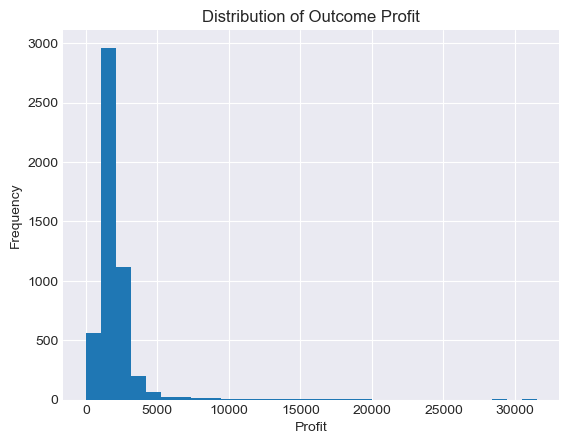

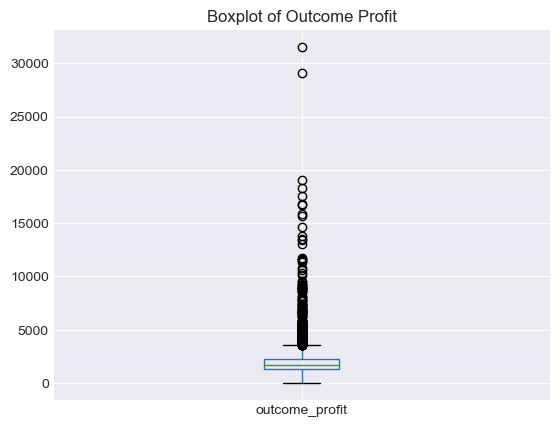

In [32]:
# Histogram Outcome Profit
train['outcome_profit'].hist(bins=30)

plt.title('Distribution of Outcome Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

# Box Plot Outcome Profit
train.boxplot(column='outcome_profit')
plt.title('Boxplot of Outcome Profit')
plt.show()

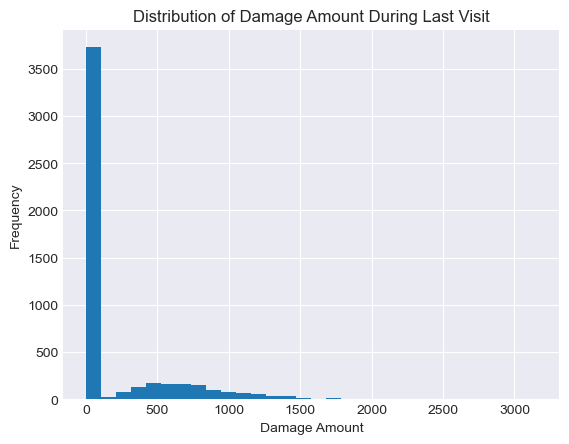

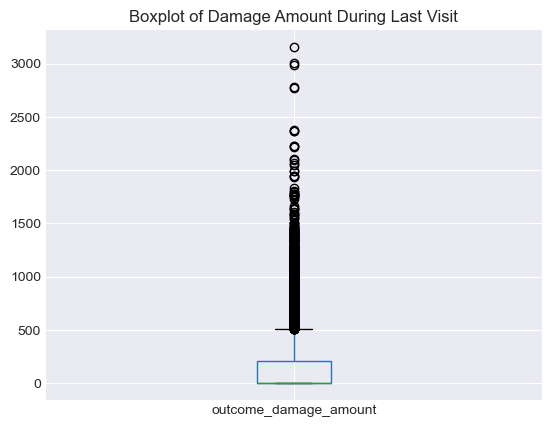

In [33]:
# Histogram of Damage Amount During Last Visit
train['outcome_damage_amount'].hist(bins=30)

plt.title('Distribution of Damage Amount During Last Visit')
plt.xlabel('Damage Amount')
plt.ylabel('Frequency')
plt.show()

# Boxplot of Damage Amount During Last Visit
train.boxplot(column='outcome_damage_amount')

plt.title('Boxplot of Damage Amount During Last Visit')
plt.show()

In [35]:
# Impute missing values according to variable type, namely, impute with modes for binary,  
# continous and descrete variables impute missing values with median (due to skewed values)

# Binary variables -> mode
binary_vars = ['gender', 'married_cd', 'gold_status']

for col in binary_vars:
    if col in datafull.columns:
        datafull[col] = datafull[col].fillna(datafull[col].mode()[0])

# All remaining numeric variables -> median
numeric_cols = datafull.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    if col not in binary_vars:
        datafull[col] = datafull[col].fillna(datafull[col].median())


In [37]:
# Standardise variables 

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

datafull_scaled = pd.DataFrame(
    scaler.fit_transform(datafull),
    columns=datafull.columns,
    index=datafull.index
)

# Keep old index
index=datafull.index

# Check result
datafull_scaled.head()

,income_am,profit_last_am,profit_am,damage_am,damage_inc,crd_lim_rec,credit_use_ic,gluten_ic,lactose_ic,insurance_ic,...,client_segment_3.0,client_segment_4.0,client_segment_5.0,client_segment_nan,sect_empl_1.0,sect_empl_2.0,sect_empl_3.0,sect_empl_4.0,sect_empl_6.0,sect_empl_nan
0,-0.251145,-0.234641,-0.078033,1.310765,6.364481,2.581952,-0.204607,-0.158025,-0.320040,-0.793492,...,-0.252238,-0.126777,-0.08341,-0.102334,3.279045,-0.090826,-0.023361,-0.072806,-0.119941,-0.102334
1,-0.246151,-0.229150,-0.346383,-0.255516,-0.396218,-0.557464,-0.204607,-0.158025,-0.320040,1.260252,...,-0.252238,-0.126777,-0.08341,-0.102334,-0.304967,-0.090826,-0.023361,-0.072806,-0.119941,-0.102334
2,-0.244324,-0.226748,-0.347973,-0.255516,-0.396218,-0.557464,-0.204607,-0.158025,-0.320040,1.260252,...,-0.252238,-0.126777,-0.08341,-0.102334,-0.304967,-0.090826,-0.023361,-0.072806,-0.119941,-0.102334
3,-0.251145,-0.234641,-0.345853,-0.255516,-0.396218,-0.722696,-0.204607,-0.158025,-0.320040,-0.793492,...,-0.252238,-0.126777,-0.08341,-0.102334,-0.304967,-0.090826,-0.023361,-0.072806,-0.119941,-0.102334
4,0.219497,0.118119,-0.038460,1.129091,1.857348,2.361642,-0.204607,-0.158025,3.124613,-0.793492,...,-0.252238,-0.126777,-0.08341,-0.102334,-0.304967,-0.090826,-0.023361,-0.072806,-0.119941,-0.102334
